# Model Evaluation — Recruiter Bot Action Classification

This notebook evaluates how well the **Main Agent** classifies recruiter turns as
`continue`, `schedule`, or `end` compared to the ground-truth labels in
`sms_conversations.json`.

**Metrics reported:**
- Overall Accuracy
- Per-class Precision, Recall, F1
- Confusion Matrix

---
**Note:** Each prediction calls the OpenAI API once (single LLM call, no advisors).
With 15 conversations and ~3 labeled turns each, expect ~45 API calls total.

## 1. Setup

In [1]:
import sys
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from dotenv import load_dotenv

# Add project root to path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

load_dotenv(os.path.join(PROJECT_ROOT, ".env"))

print("Setup complete.")
print(f"Project root: {PROJECT_ROOT}")

Setup complete.
Project root: C:\Users\chuck\Downloads\Generative_AI_LLM\final_project


## 2. Load Labeled Dataset

In [2]:
CONVERSATIONS_PATH = os.path.join(PROJECT_ROOT, "sms_conversations.json")

with open(CONVERSATIONS_PATH, "r", encoding="utf-8") as f:
    conversations = json.load(f)

print(f"Loaded {len(conversations)} conversations.")


def build_eval_samples(conversations: list) -> list[dict]:
    """
    For every recruiter turn that has a label, build:
      - history_text: the full conversation up to (and including) that turn
      - true_label:   the ground-truth action
    """
    samples = []
    for conv in conversations:
        turns = conv["turns"]
        for idx, turn in enumerate(turns):
            if turn["speaker"] != "recruiter" or turn["label"] is None:
                continue
            # Build history text
            lines = []
            for t in turns[: idx + 1]:
                role = "Recruiter" if t["speaker"] == "recruiter" else "Candidate"
                lines.append(f"{role}: {t['text']}")
            samples.append({
                "conversation_id": conv["conversation_id"],
                "turn_id": turn["turn_id"],
                "history_text": "\n".join(lines),
                "true_label": turn["label"],
            })
    return samples


samples = build_eval_samples(conversations)
df = pd.DataFrame(samples)

print(f"\nTotal labeled turns: {len(df)}")
print("\nLabel distribution:")
print(df["true_label"].value_counts())

Loaded 15 conversations.

Total labeled turns: 59

Label distribution:
true_label
continue    25
schedule    19
end         15
Name: count, dtype: int64


## 3. Run Predictions

We use `MainAgent.decide_action_only()` — a lightweight method that makes a single
LLM call per turn (no advisor agents) to classify the action.

In [3]:
from app.modules.main_agent.main_agent import MainAgent
from app.modules.exit_advisor.exit_advisor import ExitAdvisor
from app.modules.scheduling_advisor.scheduling_advisor import SchedulingAdvisor
from app.modules.info_advisor.info_advisor import InfoAdvisor

# For evaluation we only need the main agent's decision logic
agent = MainAgent(
    exit_advisor=ExitAdvisor(),
    scheduling_advisor=SchedulingAdvisor(),
    info_advisor=InfoAdvisor(),
)

print(f"Running predictions on {len(df)} turns… (one API call each)")

predictions = []
for i, row in df.iterrows():
    pred = agent.decide_action_only(row["history_text"])
    predictions.append(pred)
    print(f"  [{i+1:02d}/{len(df)}] conv={row['conversation_id']} turn={row['turn_id']} "
          f"true={row['true_label']:8s} pred={pred}")

df["predicted_label"] = predictions
print("\nDone.")

Running predictions on 59 turns… (one API call each)


  [01/59] conv=1 turn=1 true=continue pred=continue


  [02/59] conv=1 turn=3 true=schedule pred=schedule


  [03/59] conv=1 turn=5 true=schedule pred=schedule


  [04/59] conv=1 turn=7 true=end      pred=end


...

  [55/59] conv=14 turn=5 true=schedule pred=schedule


  [56/59] conv=14 turn=7 true=end      pred=end


  [57/59] conv=15 turn=1 true=continue pred=continue


  [58/59] conv=15 turn=3 true=schedule pred=schedule


  [59/59] conv=15 turn=5 true=end      pred=end

Done.


## 4. Results

In [4]:
y_true = df["true_label"]
y_pred = df["predicted_label"]

accuracy = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy: {accuracy:.1%}\n")
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=["continue", "end", "schedule"]))

Overall Accuracy: 93.2%

Classification Report:
              precision    recall  f1-score   support

    continue       0.96      0.92      0.94        25
         end       0.88      1.00      0.94        15
    schedule       0.94      0.89      0.92        19

    accuracy                           0.93        59
   macro avg       0.93      0.94      0.93        59
weighted avg       0.93      0.93      0.93        59



## 5. Confusion Matrix

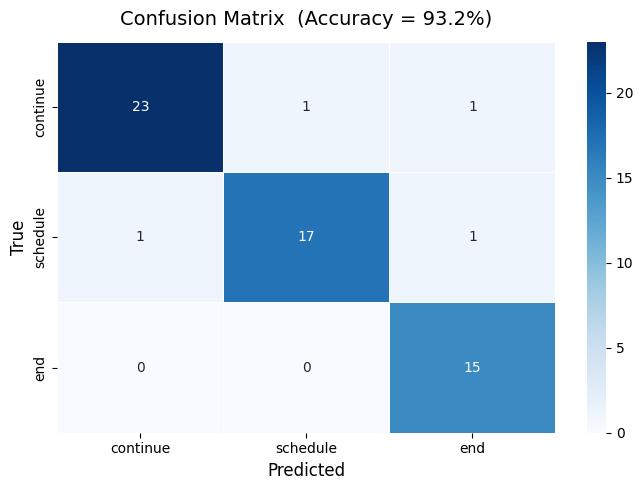

Plot saved to tests/confusion_matrix.png


In [5]:
labels = ["continue", "schedule", "end"]
cm = confusion_matrix(y_true, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    ax=ax,
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(f"Confusion Matrix  (Accuracy = {accuracy:.1%})", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "tests", "confusion_matrix.png"), dpi=150)
plt.show()
print("Plot saved to tests/confusion_matrix.png")

## 6. Detailed Results Table

In [6]:
df["correct"] = df["true_label"] == df["predicted_label"]

display_cols = ["conversation_id", "turn_id", "true_label", "predicted_label", "correct"]
styled = (
    df[display_cols]
    .style
    .map(lambda v: "background-color: #d4edda" if v is True else
                   ("background-color: #f8d7da" if v is False else ""),
         subset=["correct"])
    .set_caption("Green = correct prediction | Red = mismatch")
)
display(styled)

,conversation_id,turn_id,true_label,predicted_label,correct
0,1,1,continue,continue,True
1,1,3,schedule,schedule,True
2,1,5,schedule,schedule,True
3,1,7,end,end,True
4,2,1,continue,continue,True
5,2,3,continue,continue,True
6,2,5,continue,continue,True
7,2,7,schedule,schedule,True
8,2,9,end,end,True
9,3,1,continue,continue,True


## 7. Error Analysis

In [7]:
errors = df[df["correct"] == False][["conversation_id", "turn_id", "true_label", "predicted_label", "history_text"]]

if errors.empty:
    print("No errors — perfect score!")
else:
    print(f"{len(errors)} misclassified turns:\n")
    for _, row in errors.iterrows():
        print(f"Conv {row['conversation_id']} Turn {row['turn_id']}: "
              f"true={row['true_label']} | pred={row['predicted_label']}")
        print(f"  Last line: {row['history_text'].splitlines()[-1]}")
        print()

4 misclassified turns:

Conv 4 Turn 5: true=continue | pred=schedule
  Last line: Recruiter: Hybrid work model, with at least two days of remote work per week, will you be able to meet next Wednesday at 10 AM

Conv 8 Turn 7: true=schedule | pred=end
  Last line: Recruiter: How about next Thursday?

Conv 9 Turn 5: true=continue | pred=end
  Last line: Recruiter: Great, your interview is confirmed. Sure, We're looking for a skilled Python Developer with expertise in Python 3 and experience working with frameworks such as Django, Flask, or FastAPI. The ideal candidate should be familiar with building RESTful APIs, working with SQL or NoSQL databases, and using version control systems like Git.

Conv 13 Turn 3: true=schedule | pred=continue
  Last line: Recruiter: Could we schedule a chat this Friday at 11 AM or next Monday at 9 AM?

